In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Attention Baseline — Colab Correctness Validator            ║
# ║                                                              ║
# ║  Steps:                                                      ║
# ║  1. Run Cell 1 to upload your dump/ files                    ║
# ║  2. Run Cell 2 to validate CUDA output vs PyTorch            ║
# ║  3. Run Cell 3 to plot the error distribution                ║
# ╚══════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────
# Cell 1 — Upload dump files from your cluster
# ─────────────────────────────────────────────────────────────────

from google.colab import files
import os, numpy as np

print("Upload all 5 files from your dump/ folder:")
print("  Q.bin, K.bin, V.bin, out.bin, meta.txt")
print()

uploaded = files.upload()   # file picker appears here

# parse metadata
meta = {}
for line in uploaded["meta.txt"].decode().strip().split("\n"):
    k, v = line.split("=")
    meta[k.strip()] = int(v.strip())

B, N, d = meta["B"], meta["N"], meta["d"]
n_elem = B * N * d
print(f"\nLoaded metadata:  B={B}  N={N}  d={d}  ({n_elem:,} elements)")

# load tensors from raw float32 binary
def load_bin(name):
    data = uploaded[name]
    arr  = np.frombuffer(data, dtype=np.float32)
    assert len(arr) == n_elem, f"{name}: expected {n_elem} floats, got {len(arr)}"
    return arr.reshape(B, N, d)

Q_cuda   = load_bin("Q.bin")
K_cuda   = load_bin("K.bin")
V_cuda   = load_bin("V.bin")
out_cuda = load_bin("out.bin")

print("✅ All tensors loaded successfully")
print(f"   Q shape: {Q_cuda.shape}   dtype: {Q_cuda.dtype}")


# ─────────────────────────────────────────────────────────────────
# Cell 2 — Compute PyTorch reference and compare
# ─────────────────────────────────────────────────────────────────

import torch
import torch.nn.functional as F

# convert to torch tensors (CPU — no GPU needed in Colab for this)
Q_t = torch.from_numpy(Q_cuda)
K_t = torch.from_numpy(K_cuda)
V_t = torch.from_numpy(V_cuda)

with torch.no_grad():
    # mirrors exactly what the CUDA kernels do:
    scores  = torch.bmm(Q_t, K_t.transpose(-1, -2)) / (d ** 0.5)  # [B, N, N]
    weights = F.softmax(scores, dim=-1)                             # [B, N, N]
    ref_out = torch.bmm(weights, V_t)                               # [B, N, d]

ref_np = ref_out.numpy()

# compute error metrics
abs_err  = np.abs(out_cuda - ref_np)
max_err  = abs_err.max()
mean_err = abs_err.mean()
rel_err  = max_err / (np.abs(ref_np).max() + 1e-8)

ATOL = 1e-3   # tolerance: float32 global-mem ops are not bit-exact vs PyTorch

print("=" * 52)
print("  Correctness Report")
print("=" * 52)
print(f"  Max  absolute error : {max_err:.6e}  {'✅' if max_err  <= ATOL else '❌'}")
print(f"  Mean absolute error : {mean_err:.6e}")
print(f"  Max  relative error : {rel_err:.6e}")
print(f"  Tolerance  (atol)   : {ATOL:.6e}")
print("=" * 52)

if max_err <= ATOL:
    print("\n  ✅ PASS — CUDA output matches PyTorch within tolerance")
else:
    print("\n  ❌ FAIL — max error exceeds tolerance")
    flat_idx = abs_err.argmax()
    b_i, n_i, d_i = np.unravel_index(flat_idx, (B, N, d))
    print(f"\n  Worst mismatch at [b={b_i}, n={n_i}, d={d_i}]")
    print(f"    CUDA output : {out_cuda[b_i, n_i, d_i]:.8f}")
    print(f"    PyTorch ref : {ref_np[b_i, n_i, d_i]:.8f}")
    print(f"    Difference  : {abs_err[b_i, n_i, d_i]:.8f}")

    # hint: if error is large and uniform, likely a scaling bug (sqrt(d))
    # if error is NaN, likely a softmax numerical stability issue
    nan_count = np.isnan(out_cuda).sum()
    if nan_count > 0:
        print(f"\n  ⚠️  {nan_count} NaN values found — check softmax stability")


# ─────────────────────────────────────────────────────────────────
# Cell 3 — Error distribution plot
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"CUDA vs PyTorch Error  |  B={B}  N={N}  d={d}", fontsize=13)

# histogram of absolute errors
axes[0].hist(abs_err.flatten(), bins=60, color="steelblue", edgecolor="none")
axes[0].axvline(ATOL, color="red", linestyle="--", label=f"atol={ATOL}")
axes[0].set_xlabel("Absolute error")
axes[0].set_ylabel("Count")
axes[0].set_title("Error Distribution")
axes[0].legend()

# heatmap of first batch's error matrix (first 64 tokens for readability)
n_show = min(N, 64)
err_slice = abs_err[0, :n_show, :].mean(axis=-1)          # mean over d dim
axes[1].imshow(err_slice.reshape(1, -1), aspect="auto",
               cmap="hot", interpolation="nearest")
axes[1].set_title(f"Mean error per token (batch 0, first {n_show} tokens)")
axes[1].set_xlabel("Token index")
axes[1].set_yticks([])
plt.colorbar(axes[1].images[0], ax=axes[1], label="Mean abs error")

plt.tight_layout()
plt.savefig("error_plot.png", dpi=150)
plt.show()
print("Plot saved: error_plot.png")


# ─────────────────────────────────────────────────────────────────
# Cell 4 — (Optional) validate results.csv throughput sanity check
# ─────────────────────────────────────────────────────────────────

import pandas as pd

try:
    csv_upload = files.upload()   # upload your results.csv
    csv_name   = list(csv_upload.keys())[0]
    df = pd.read_csv(csv_name)
    print(df.to_string(index=False))

    # sanity: throughput = B*N / (latency_ms / 1000)
    df["expected_throughput"] = (df["B"] * df["N"]) / (df["latency_ms"] / 1000.0) / 1e3
    df["throughput_error_%"]  = ((df["throughput_k_tokens_per_sec"] - df["expected_throughput"])
                                  / df["expected_throughput"] * 100).abs()
    print("\nThroughput sanity check (should be ~0%):")
    print(df[["variant","B","N","d","latency_ms","throughput_k_tokens_per_sec",
              "expected_throughput","throughput_error_%"]].to_string(index=False))
except Exception as e:
    print(f"(Skipped CSV check: {e})")

Upload all 5 files from your dump/ folder:
  Q.bin, K.bin, V.bin, out.bin, meta.txt



KeyError: 'meta.txt'

Saving baseline_sweep.csv to baseline_sweep.csv
Loaded 32 rows from baseline_sweep.csv
 variant  B    N   d  latency_ms  throughput_k_tokens_per_sec                  timestamp
baseline  1  128  64      0.0991                      1291.72 2026-03-11T23:33:56.330970
baseline  1  128 128      0.1046                      1223.69 2026-03-11T23:33:56.649157
baseline  1  256  64      0.3365                       760.73 2026-03-11T23:33:56.998349
baseline  1  256 128      0.3557                       719.69 2026-03-11T23:33:57.347285
baseline  1  512  64      0.6969                       734.64 2026-03-11T23:33:57.727907
baseline  1  512 128      0.7656                       668.74 2026-03-11T23:33:58.122277
baseline  1 1024  64      1.5271                       670.53 2026-03-11T23:33:58.595170
baseline  1 1024 128      1.8238                       561.45 2026-03-11T23:33:59.106109
baseline  4  128  64      0.1139                      4495.59 2026-03-11T23:33:59.432219
baseline  4  128 128   

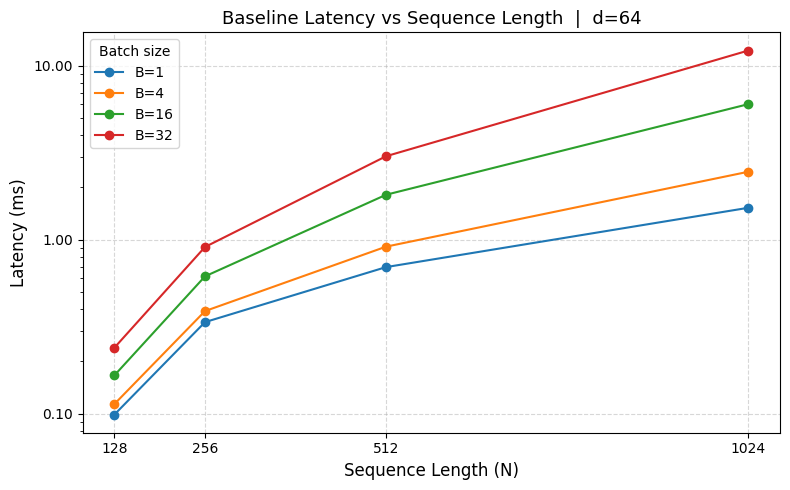

Saved: latency_vs_N_d64.png


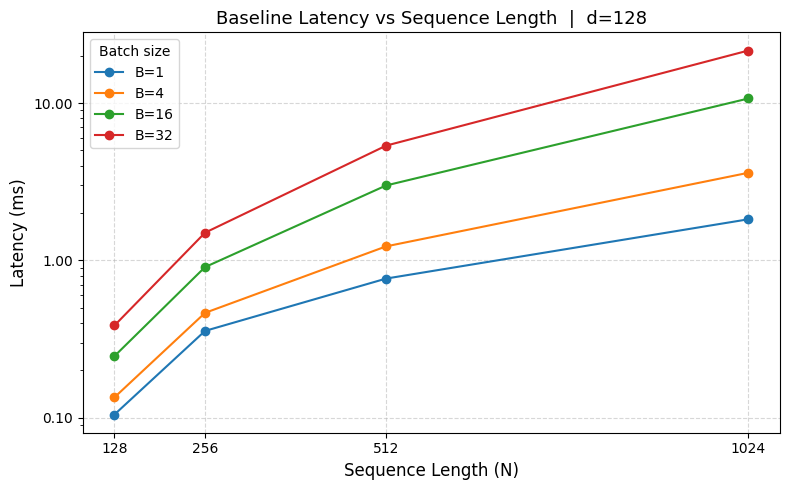

Saved: latency_vs_N_d128.png


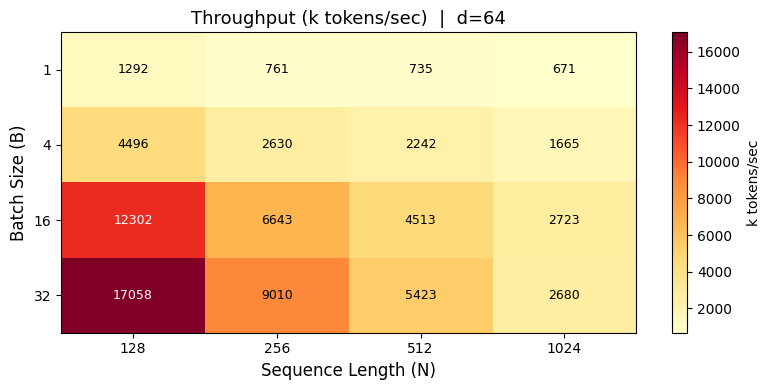

Saved: throughput_heatmap_d64.png


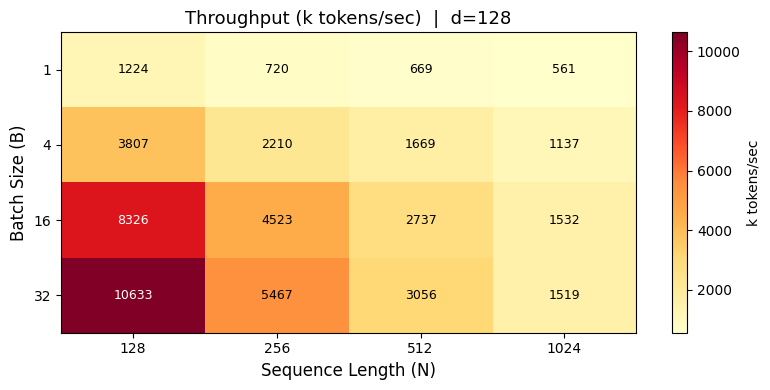

Saved: throughput_heatmap_d128.png

=== Scaling Analysis (latency ratio when N doubles) ===
   B    d  N_low  N_high   lat_low   lat_high   ratio  expected
   1   64    128     256     0.099      0.337    3.40x (~4x expected)
   1   64    256     512     0.337      0.697    2.07x (~4x expected)
   1   64    512    1024     0.697      1.527    2.19x (~4x expected)

   1  128    128     256     0.105      0.356    3.40x (~4x expected)
   1  128    256     512     0.356      0.766    2.15x (~4x expected)
   1  128    512    1024     0.766      1.824    2.38x (~4x expected)

   4   64    128     256     0.114      0.389    3.42x (~4x expected)
   4   64    256     512     0.389      0.913    2.35x (~4x expected)
   4   64    512    1024     0.913      2.460    2.69x (~4x expected)

   4  128    128     256     0.135      0.463    3.44x (~4x expected)
   4  128    256     512     0.463      1.227    2.65x (~4x expected)
   4  128    512    1024     1.227      3.603    2.94x (~4x expected)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  Phase 2 — Benchmark Results Analysis (run in Colab)            ║
# ║                                                                  ║
# ║  Upload baseline_sweep.csv when prompted.                       ║
# ║  Produces 3 plots saved as PNGs for your repo and paper.        ║
# ╚══════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────
# Cell 1 — Upload CSV
# ─────────────────────────────────────────────────────────────────

from google.colab import files
import pandas as pd
import io

uploaded = files.upload()
fname = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[fname]))

print(f"Loaded {len(df)} rows from {fname}")
print(df.to_string(index=False))


# ─────────────────────────────────────────────────────────────────
# Cell 2 — Latency vs Sequence Length
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# separate by head dim
for d_val in sorted(df["d"].unique()):
    sub = df[df["d"] == d_val]

    fig, ax = plt.subplots(figsize=(8, 5))

    for B_val in sorted(sub["B"].unique()):
        grp = sub[sub["B"] == B_val].sort_values("N")
        ax.plot(grp["N"], grp["latency_ms"],
                marker="o", label=f"B={B_val}")

    ax.set_xlabel("Sequence Length (N)", fontsize=12)
    ax.set_ylabel("Latency (ms)", fontsize=12)
    ax.set_title(f"Baseline Latency vs Sequence Length  |  d={d_val}", fontsize=13)
    ax.set_xticks(sorted(sub["N"].unique()))
    ax.legend(title="Batch size", loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_yscale("log")           # log scale reveals O(N²) growth clearly
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

    plt.tight_layout()
    fname_out = f"latency_vs_N_d{d_val}.png"
    plt.savefig(fname_out, dpi=150)
    plt.show()
    print(f"Saved: {fname_out}")


# ─────────────────────────────────────────────────────────────────
# Cell 3 — Throughput Heatmap (B × N)
# ─────────────────────────────────────────────────────────────────

for d_val in sorted(df["d"].unique()):
    sub = df[df["d"] == d_val]

    pivot = sub.pivot(index="B", columns="N",
                      values="throughput_k_tokens_per_sec")

    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Sequence Length (N)", fontsize=12)
    ax.set_ylabel("Batch Size (B)", fontsize=12)
    ax.set_title(f"Throughput (k tokens/sec)  |  d={d_val}", fontsize=13)

    # annotate cells
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                    fontsize=9,
                    color="black" if val < pivot.values.max() * 0.7 else "white")

    plt.colorbar(im, ax=ax, label="k tokens/sec")
    plt.tight_layout()
    fname_out = f"throughput_heatmap_d{d_val}.png"
    plt.savefig(fname_out, dpi=150)
    plt.show()
    print(f"Saved: {fname_out}")


# ─────────────────────────────────────────────────────────────────
# Cell 4 — Latency Scaling Analysis (verify O(N²) growth)
# ─────────────────────────────────────────────────────────────────

print("\n=== Scaling Analysis (latency ratio when N doubles) ===")
print(f"{'B':>4} {'d':>4} {'N_low':>6} {'N_high':>7} {'lat_low':>9} "
      f"{'lat_high':>10} {'ratio':>7} {'expected':>9}")

for B_val in sorted(df["B"].unique()):
    for d_val in sorted(df["d"].unique()):
        grp = df[(df["B"] == B_val) & (df["d"] == d_val)].sort_values("N")
        lats = grp["latency_ms"].values
        Ns   = grp["N"].values
        for i in range(len(Ns) - 1):
            ratio = lats[i+1] / lats[i]
            print(f"{B_val:>4} {d_val:>4} {Ns[i]:>6} {Ns[i+1]:>7} "
                  f"{lats[i]:>9.3f} {lats[i+1]:>10.3f} {ratio:>7.2f}x "
                  f"{'(~4x expected)':>9}")
        print()

# If ratios are ~4x when N doubles → O(N²) confirmed (attention is quadratic)
# If ratios are much less → memory bandwidth is already saturated at small N


# ─────────────────────────────────────────────────────────────────
# Cell 5 — Summary table (copy into your report)
# ─────────────────────────────────────────────────────────────────

print("\n=== Summary Table (for paper / report) ===\n")
summary = df[["variant","B","N","d","latency_ms","throughput_k_tokens_per_sec"]]
print(summary.to_markdown(index=False))

# Download all generated plots
from google.colab import files as colab_files
import glob
for f in glob.glob("*.png"):
    colab_files.download(f)